# **INTERNET SPEED PREDICTION**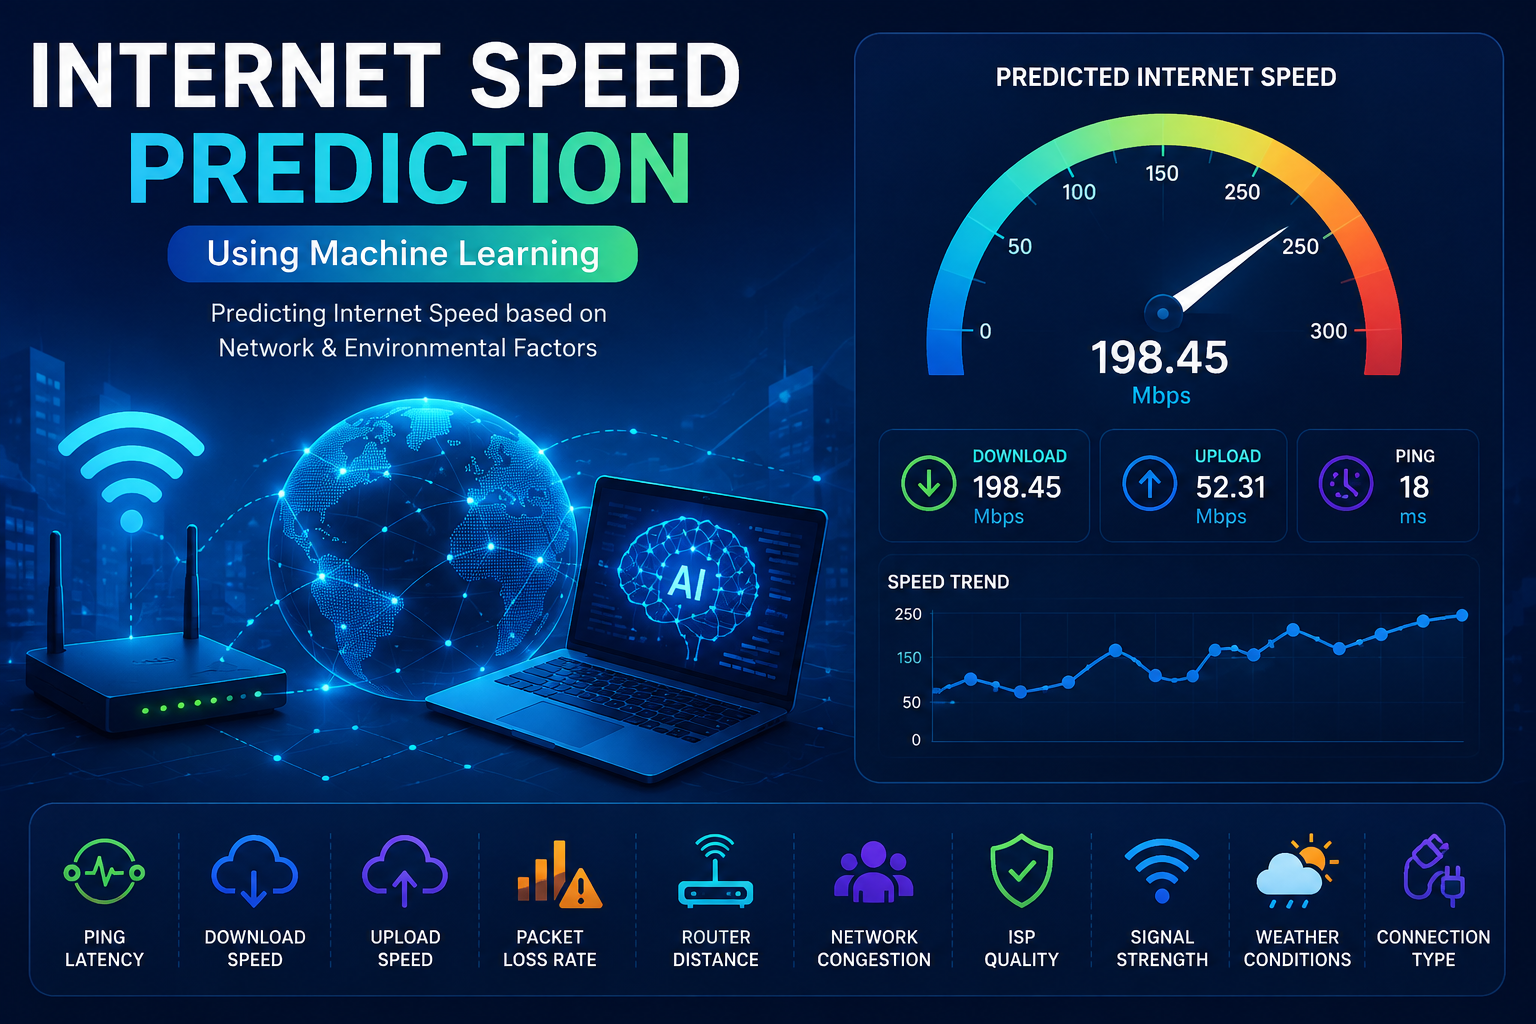

# **INTRODUCTION**

Internet connectivity has become an essential part of everyday life, and the quality of an internet connection can significantly affect activities such as video streaming, online gaming, video conferencing, cloud computing, and web browsing. Internet speed can be influenced by several network-related factors, including download speed, upload speed, ping latency, signal strength, packet loss, network congestion, connection type, ISP quality, router distance, and weather conditions.

The objective of this project is to develop a machine learning model that can predict Internet Speed based on available network-related features. Since the target variable is continuous, this problem is treated as a regression problem.

The project follows a complete machine learning workflow consisting of Exploratory Data Analysis (EDA), feature selection, data preprocessing, regression model development, hyperparameter tuning, model evaluation, and prediction on unseen data.

Three regression algorithms were considered:

1. Linear Regression (LR)
2. K-Nearest Neighbors Regression (KNN)
3. Support Vector Regression (SVR)

The models were compared using R² Score, Mean Absolute Error (MAE), and Root Mean Squared Error (RMSE). The model with the best overall predictive performance was selected as the final model.

**DATASET ANALYSIS**

The dataset contains 5,000 observations with different network-related features and the target variable Internet_speed.

The features include variables related to:

1. Download speed
2. Upload speed
3. Ping latency
4. Packet loss rate
5. Signal strength
6. Network congestion
7. ISP quality
8. Router distance
9. Weather conditions
10. Connection type Cable
11. Connection type DSL
12. Connection type Fiber

The target variable is ***Internet Speed***.

Since Internet Speed is a continuous numerical value, regression algorithms are appropriate for this prediction task.


**DATA LOADING**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
import numpy as np
from sklearn.model_selection import GridSearchCV

In [ ]:
df=pd.read_csv("/content/drive/MyDrive/Internet Speed.csv")
df

,Ping_latency,Download_speed,Upload_speed,Packet_loss_rate,Router_distance,Network_congestion,ISP_quality,Connection_type_DSL,Connection_type_Cable,Connection_type_Fiber,Signal_strength,Weather_conditions,Internet_speed
0,21.854305,42.395374,19.934759,0.999340,7.569985,1.369483,7.467012,0.000000,0.000000,0.000000,76.190258,2.552049,730.336287
1,47.782144,49.976388,17.979781,1.493494,2.660608,1.243015,6.215047,2.373401,0.000000,3.869607,70.945684,2.788454,994.148168
2,37.939727,86.182002,10.455388,1.125334,4.119757,3.416768,9.751490,1.509861,0.000000,2.332773,83.994324,3.098587,2551.867438
3,31.939632,37.300417,31.148800,0.166605,6.969526,4.864465,4.532849,0.000000,0.000000,1.608198,92.278904,4.479742,621.336539
4,12.020839,87.616720,24.877960,0.371160,5.338804,3.010885,7.114995,1.241954,0.000000,2.693502,80.535702,4.190802,2612.315499
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,45.382879,86.477319,33.242407,1.754077,3.947383,4.809102,6.040825,0.000000,3.112226,2.456354,92.054785,0.720499,2600.889238
4996,10.372146,90.263339,10.534320,0.093628,7.542697,3.991297,6.245036,0.000000,0.000000,0.000000,97.745403,1.598590,2769.740618
4997,19.752928,94.937252,4.459498,0.607397,9.309467,1.077823,6.707668,0.011109,3.744975,1.019031,97.209409,2.218448,3031.079831
4998,41.708542,42.761359,34.782156,0.886640,6.735571,2.604019,9.772978,0.000000,0.000000,3.915730,96.801547,2.196325,818.064550


In [ ]:
df.head()

,Ping_latency,Download_speed,Upload_speed,Packet_loss_rate,Router_distance,Network_congestion,ISP_quality,Connection_type_DSL,Connection_type_Cable,Connection_type_Fiber,Signal_strength,Weather_conditions,Internet_speed
0,21.854305,42.395374,19.934759,0.999340,7.569985,1.369483,7.467012,0.000000,0.0,0.000000,76.190258,2.552049,730.336287
1,47.782144,49.976388,17.979781,1.493494,2.660608,1.243015,6.215047,2.373401,0.0,3.869607,70.945684,2.788454,994.148168
2,37.939727,86.182002,10.455388,1.125334,4.119757,3.416768,9.751490,1.509861,0.0,2.332773,83.994324,3.098587,2551.867438
3,31.939632,37.300417,31.148800,0.166605,6.969526,4.864465,4.532849,0.000000,0.0,1.608198,92.278904,4.479742,621.336539
4,12.020839,87.616720,24.877960,0.371160,5.338804,3.010885,7.114995,1.241954,0.0,2.693502,80.535702,4.190802,2612.315499


**DATA UNDERSTANDING**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Ping_latency           5000 non-null   float64
 1   Download_speed         5000 non-null   float64
 2   Upload_speed           5000 non-null   float64
 3   Packet_loss_rate       5000 non-null   float64
 4   Router_distance        5000 non-null   float64
 5   Network_congestion     5000 non-null   float64
 6   ISP_quality            5000 non-null   float64
 7   Connection_type_DSL    5000 non-null   float64
 8   Connection_type_Cable  5000 non-null   float64
 9   Connection_type_Fiber  5000 non-null   float64
 10  Signal_strength        5000 non-null   float64
 11  Weather_conditions     5000 non-null   float64
 12  Internet_speed         5000 non-null   float64
dtypes: float64(13)
memory usage: 507.9 KB


In [ ]:
df.describe()

,Ping_latency,Download_speed,Upload_speed,Packet_loss_rate,Router_distance,Network_congestion,ISP_quality,Connection_type_DSL,Connection_type_Cable,Connection_type_Fiber,Signal_strength,Weather_conditions,Internet_speed
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,27.357440,51.691277,26.066003,1.015369,5.578994,2.965295,6.504300,1.272947,1.256751,1.273640,84.948302,2.499880,1257.296163
std,13.033514,27.133568,13.956951,0.575612,2.598671,1.138216,2.018279,1.637940,1.625825,1.631132,8.609663,1.438197,927.617450
min,5.000524,5.005019,2.007572,0.000505,1.000433,1.000441,3.000039,0.000000,0.000000,0.000000,70.001406,0.003471,80.606669
25%,15.973826,28.478861,13.864032,0.525459,3.330062,1.988582,4.732669,0.000000,0.000000,0.000000,77.742714,1.244065,430.808067
50%,27.500388,51.167300,25.817462,1.024899,5.620063,2.963910,6.513309,0.032340,0.002561,0.031585,84.822169,2.511349,1018.976847
75%,38.664539,74.670302,38.509712,1.502211,7.819270,3.928608,8.237586,2.537834,2.507974,2.547957,92.345908,3.771796,1951.295923
max,49.987295,99.952993,49.990647,1.999850,9.999109,4.998928,9.998526,4.999453,4.999785,4.998248,99.998191,4.998094,3364.871190


**DATA CLEANING**

In [ ]:
df.drop_duplicates()

,Ping_latency,Download_speed,Upload_speed,Packet_loss_rate,Router_distance,Network_congestion,ISP_quality,Connection_type_DSL,Connection_type_Cable,Connection_type_Fiber,Signal_strength,Weather_conditions,Internet_speed
0,21.854305,42.395374,19.934759,0.999340,7.569985,1.369483,7.467012,0.000000,0.000000,0.000000,76.190258,2.552049,730.336287
1,47.782144,49.976388,17.979781,1.493494,2.660608,1.243015,6.215047,2.373401,0.000000,3.869607,70.945684,2.788454,994.148168
2,37.939727,86.182002,10.455388,1.125334,4.119757,3.416768,9.751490,1.509861,0.000000,2.332773,83.994324,3.098587,2551.867438
3,31.939632,37.300417,31.148800,0.166605,6.969526,4.864465,4.532849,0.000000,0.000000,1.608198,92.278904,4.479742,621.336539
4,12.020839,87.616720,24.877960,0.371160,5.338804,3.010885,7.114995,1.241954,0.000000,2.693502,80.535702,4.190802,2612.315499
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,45.382879,86.477319,33.242407,1.754077,3.947383,4.809102,6.040825,0.000000,3.112226,2.456354,92.054785,0.720499,2600.889238
4996,10.372146,90.263339,10.534320,0.093628,7.542697,3.991297,6.245036,0.000000,0.000000,0.000000,97.745403,1.598590,2769.740618
4997,19.752928,94.937252,4.459498,0.607397,9.309467,1.077823,6.707668,0.011109,3.744975,1.019031,97.209409,2.218448,3031.079831
4998,41.708542,42.761359,34.782156,0.886640,6.735571,2.604019,9.772978,0.000000,0.000000,3.915730,96.801547,2.196325,818.064550


In [ ]:
df.isna().sum()

,0
Ping_latency,0
Download_speed,0
Upload_speed,0
Packet_loss_rate,0
Router_distance,0
Network_congestion,0
ISP_quality,0
Connection_type_DSL,0
Connection_type_Cable,0
Connection_type_Fiber,0


In [ ]:
df.dtypes

,0
Ping_latency,float64
Download_speed,float64
Upload_speed,float64
Packet_loss_rate,float64
Router_distance,float64
Network_congestion,float64
ISP_quality,float64
Connection_type_DSL,float64
Connection_type_Cable,float64
Connection_type_Fiber,float64


**DATA VISUALIZATION**

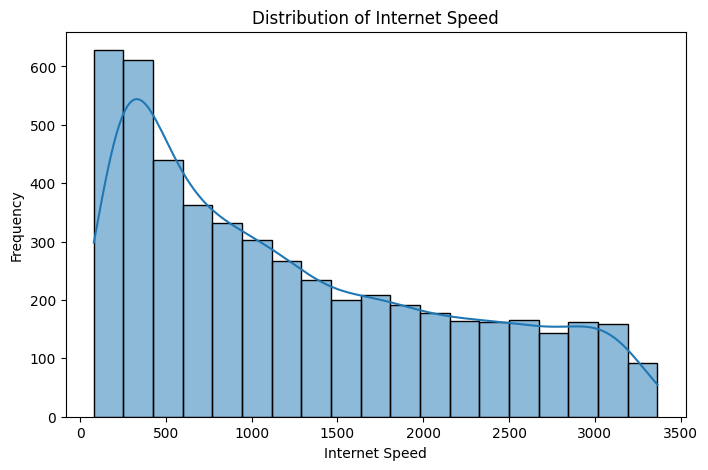

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df["Internet_speed"], kde=True)
plt.title("Distribution of Internet Speed")
plt.xlabel("Internet Speed")
plt.ylabel("Frequency")
plt.show()

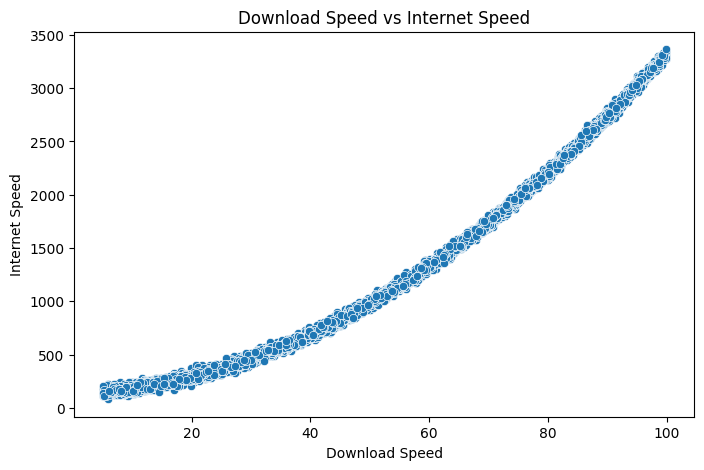

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df,x="Download_speed",y="Internet_speed")
plt.title("Download Speed vs Internet Speed")
plt.xlabel("Download Speed")
plt.ylabel("Internet Speed")
plt.show()

**FEATURE SELECTION**

In [ ]:
df.corr()

,Ping_latency,Download_speed,Upload_speed,Packet_loss_rate,Router_distance,Network_congestion,ISP_quality,Connection_type_DSL,Connection_type_Cable,Connection_type_Fiber,Signal_strength,Weather_conditions,Internet_speed
Ping_latency,1.000000,-0.007017,-0.009517,0.028672,-0.011310,-0.017431,-0.015415,-0.009626,0.015357,0.011046,-0.003596,-0.031202,-0.000861
Download_speed,-0.007017,1.000000,-0.022831,-0.000423,0.009986,-0.007908,-0.018289,0.028122,0.001483,-0.010740,0.001845,0.008815,0.975699
Upload_speed,-0.009517,-0.022831,1.000000,0.007119,-0.027433,0.023695,-0.014841,0.026959,-0.012848,0.000412,-0.044703,0.000877,-0.004202
Packet_loss_rate,0.028672,-0.000423,0.007119,1.000000,0.010196,-0.020278,-0.022456,0.014866,0.004882,-0.032766,0.017904,0.021842,-0.001732
Router_distance,-0.011310,0.009986,-0.027433,0.010196,1.000000,-0.010684,-0.016746,0.005220,0.004775,0.001081,0.004280,0.012505,0.010041
Network_congestion,-0.017431,-0.007908,0.023695,-0.020278,-0.010684,1.000000,0.025701,0.011865,0.000529,0.025461,0.039788,0.000598,0.000018
ISP_quality,-0.015415,-0.018289,-0.014841,-0.022456,-0.016746,0.025701,1.000000,-0.025370,0.003804,-0.009783,-0.000594,0.008871,-0.015351
Connection_type_DSL,-0.009626,0.028122,0.026959,0.014866,0.005220,0.011865,-0.025370,1.000000,0.009952,0.004400,0.005887,0.015861,0.020906
Connection_type_Cable,0.015357,0.001483,-0.012848,0.004882,0.004775,0.000529,0.003804,0.009952,1.000000,0.007921,0.019018,-0.005282,0.007339
Connection_type_Fiber,0.011046,-0.010740,0.000412,-0.032766,0.001081,0.025461,-0.009783,0.004400,0.007921,1.000000,0.019631,0.016793,0.000194


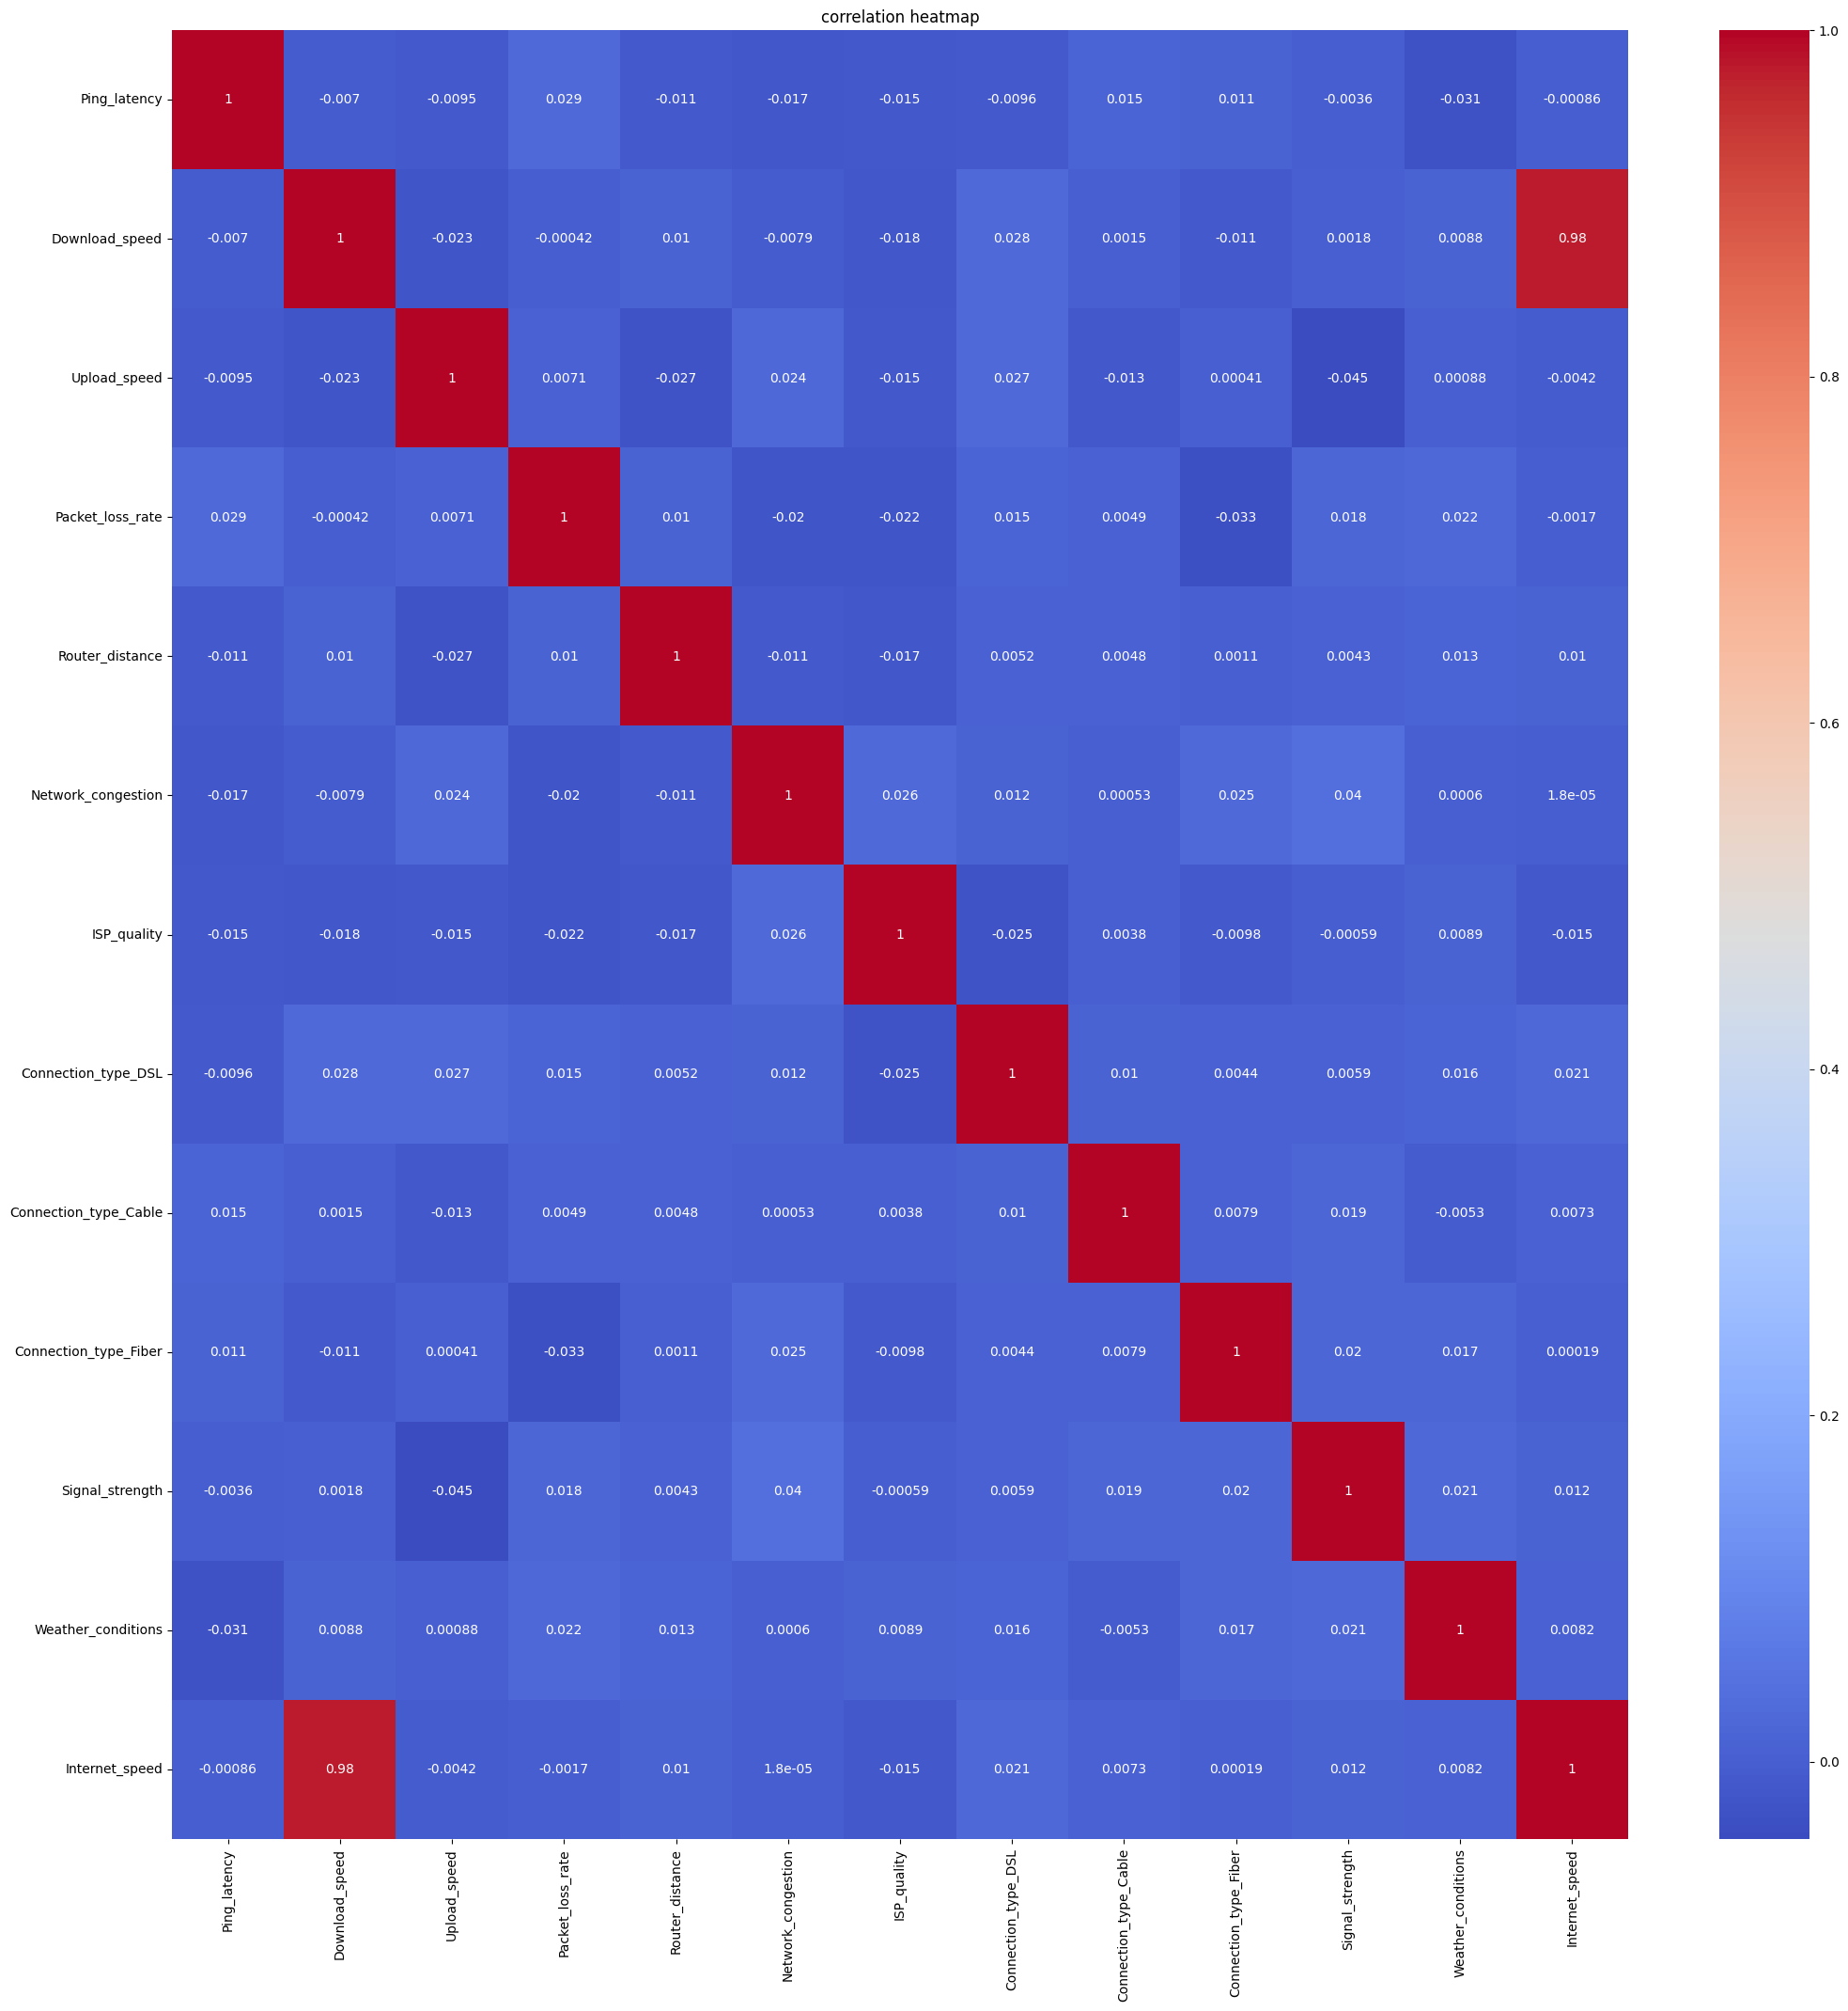

In [ ]:
plt.figure(figsize=(25,25))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm')
plt.title("correlation heatmap")
plt.show()

In [ ]:
corr_matrix = df.corr()
corr_with_target = corr_matrix['Internet_speed'].sort_values(ascending=False)
print(corr_with_target)

Internet_speed           1.000000
Download_speed           0.975699
Connection_type_DSL      0.020906
Signal_strength          0.011692
Router_distance          0.010041
Weather_conditions       0.008200
Connection_type_Cable    0.007339
Connection_type_Fiber    0.000194
Network_congestion       0.000018
Ping_latency            -0.000861
Packet_loss_rate        -0.001732
Upload_speed            -0.004202
ISP_quality             -0.015351
Name: Internet_speed, dtype: float64


**EXTRACT FEATURES AND TARGET VARIABLE**

In [ ]:
selected_features=['Download_speed','Connection_type_DSL','Signal_strength','Router_distance','Weather_conditions','Connection_type_Cable','Connection_type_Fiber','Network_congestion']
x=df[selected_features]
y=df['Internet_speed']

In [ ]:
x

,Download_speed,Connection_type_DSL,Signal_strength,Router_distance,Weather_conditions,Connection_type_Cable,Connection_type_Fiber,Network_congestion
0,42.395374,0.000000,76.190258,7.569985,2.552049,0.000000,0.000000,1.369483
1,49.976388,2.373401,70.945684,2.660608,2.788454,0.000000,3.869607,1.243015
2,86.182002,1.509861,83.994324,4.119757,3.098587,0.000000,2.332773,3.416768
3,37.300417,0.000000,92.278904,6.969526,4.479742,0.000000,1.608198,4.864465
4,87.616720,1.241954,80.535702,5.338804,4.190802,0.000000,2.693502,3.010885
...,...,...,...,...,...,...,...,...
4995,86.477319,0.000000,92.054785,3.947383,0.720499,3.112226,2.456354,4.809102
4996,90.263339,0.000000,97.745403,7.542697,1.598590,0.000000,0.000000,3.991297
4997,94.937252,0.011109,97.209409,9.309467,2.218448,3.744975,1.019031,1.077823
4998,42.761359,0.000000,96.801547,6.735571,2.196325,0.000000,3.915730,2.604019


In [ ]:
y

,Internet_speed
0,730.336287
1,994.148168
2,2551.867438
3,621.336539
4,2612.315499
...,...
4995,2600.889238
4996,2769.740618
4997,3031.079831
4998,818.064550


**FEATURE SCALING**

In [ ]:
scaler=MinMaxScaler()
x_scaled=scaler.fit_transform(x)
x_scaled

array([[0.39379835, 0.        , 0.20631719, ..., 0.        , 0.        ,
        0.09229551],
       [0.47364222, 0.47473224, 0.03147931, ..., 0.        , 0.77419277,
        0.06066644],
       [0.85496278, 0.30200519, 0.46648058, ..., 0.        , 0.4667182 ,
        0.60431024],
       ...,
       [0.9471738 , 0.00222209, 0.90703065, ..., 0.74902733, 0.20387758,
        0.01935295],
       [0.39765294, 0.        , 0.89343379, ..., 0.        , 0.78342064,
        0.40104627],
       [0.21720653, 0.        , 0.8831264 , ..., 0.8617438 , 0.49739972,
        0.25738508]])

**DATA SPLITTING**

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=1)

**MODEL CREATION**

In [ ]:
lr=LinearRegression()
knr=KNeighborsRegressor()
svr=SVR()

**Linear Regression**

In [ ]:
lr.fit(x_train,y_train)
y_pred=lr.predict(x_test)
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
print("r2 score:",r2_score(y_test,y_pred)*100)
print("mae:", mean_absolute_error(y_test, y_pred))
print("rmse:", np.sqrt(mean_squared_error(y_test, y_pred)))

r2 score: 94.90903159381891
mae: 177.87204518199806
rmse: 206.4829312171557


**K-Nearest Neighbors Regression**

In [ ]:
knr.fit(x_train,y_train)
y_pred1=knr.predict(x_test)
print("r2 score:",r2_score(y_test,y_pred1)*100)
print("mae:", mean_absolute_error(y_test, y_pred))
print("rmse:", np.sqrt(mean_squared_error(y_test, y_pred)))

r2 score: 99.81994631272292
mae: 177.87204518199806
rmse: 206.4829312171557


**Support Vector Regression**

In [ ]:
svr.fit(x_train,y_train)
y_pred2=svr.predict(x_test)
print("r2 score:",r2_score(y_test,y_pred2)*100)
print("mae:", mean_absolute_error(y_test, y_pred))
print("rmse:", np.sqrt(mean_squared_error(y_test, y_pred)))

r2 score: 60.35788529319286
mae: 177.87204518199806
rmse: 206.4829312171557


**HYPERPARAMETER TUNING**

**K-Nearest Neighbors Regression**

In [ ]:
params={'n_neighbors':[3,5,7,9],'weights':['uniform','distance'],'algorithm':['auto','ball_tree','kd_tree','brute']}
gcv=GridSearchCV(knr,params,cv=10,n_jobs=1)
gcv.fit(x_train,y_train)

GridSearchCV(cv=10, estimator=KNeighborsRegressor(), n_jobs=1,
             param_grid={'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
                         'n_neighbors': [3, 5, 7, 9],
                         'weights': ['uniform', 'distance']})

In [ ]:
print(gcv.best_params_)

{'algorithm': 'brute', 'n_neighbors': 9, 'weights': 'distance'}


In [ ]:
knr1=KNeighborsRegressor(algorithm='brute',n_neighbors=9,weights='distance')
knr1.fit(x_train,y_train)
y_pred3=knr1.predict(x_test)
print(r2_score(y_test,y_pred3)*100)
print("mae:", mean_absolute_error(y_test, y_pred3))
print("rmse:", np.sqrt(mean_squared_error(y_test, y_pred3)))

99.8566159488255
mae: 26.309018722606307
rmse: 34.6524846045899


**Support Vector Regression**

In [ ]:
params = {'C': [0.1, 1, 10],'gamma': ['scale', 'auto']}
gcv1 = GridSearchCV(estimator=SVR(cache_size=1000),param_grid=params,cv=10,n_jobs=-1,verbose=2)
gcv1.fit(x_train, y_train)
print("Best Parameters:", gcv1.best_params_)

Fitting 10 folds for each of 6 candidates, totalling 60 fits
Best Parameters: {'C': 10, 'gamma': 'scale'}


In [ ]:
svr1=SVR(C=10,gamma='scale')
svr1.fit(x_train,y_train)
y_pred4=svr1.predict(x_test)
print(r2_score(y_test,y_pred4)*100)
print("mae:", mean_absolute_error(y_test, y_pred4))
print("rmse:", np.sqrt(mean_squared_error(y_test, y_pred4)))

98.94693213194921
mae: 54.81216960914908
rmse: 93.91006401519412


**COMPARE TRAINING AND TESTING ACCURACY**

In [ ]:
y_train_pred = knr1.predict(x_train)
y_test_pred = knr1.predict(x_test)
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
print("Training R2 Accuracy :", train_r2 * 100, "%")
print("Testing R2 Accuracy  :", test_r2 * 100, "%")

Training R2 Accuracy : 99.9999999999998 %
Testing R2 Accuracy  : 99.8566159488255 %


**TESTING THE KNR MODEL**

In [ ]:
sample = x_test.iloc[[0]]

actual_speed = y_test.iloc[0]

predicted_speed = knr1.predict(sample)[0]

error = abs(actual_speed - predicted_speed)

percentage_error = (error / actual_speed) * 100

print("Actual Internet Speed   :", actual_speed)
print("Predicted Internet Speed:", predicted_speed)
print("Prediction Error        :", error)
print("Percentage Error        :", percentage_error, "%")

Actual Internet Speed   : 1616.011518438763
Predicted Internet Speed: 1590.9496660871785
Prediction Error        : 25.061852351584548
Percentage Error        : 1.5508461459357006 %


**TESTING THE IMPORTANCE OF DOWNLOAD SPEED**

In [ ]:
features_without_download = ["Upload_speed","Signal_strength","Connection_type_Fiber","Connection_type_DSL","Ping_latency","Connection_type_Cable","ISP_quality","Router_distance","Weather_conditions"]

X = df[features_without_download]
y = df["Internet_speed"]

x_train, x_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42)

knr_no_download = Pipeline([("scaler", StandardScaler()),("knn", KNeighborsRegressor(n_neighbors=9,weights="distance",algorithm="auto"))])

knr_no_download.fit(x_train, y_train)

pred = knr_no_download.predict(x_test)

print("KNN without Download_speed")
print("R2   :", r2_score(y_test, pred))
print("MAE  :", mean_absolute_error(y_test, pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, pred)))

KNN without Download_speed
R2   : -0.12886975097964037
MAE  : 834.5376413643479
RMSE : 988.3919294396998


# **CONCLUSION**

This project developed a machine learning model for predicting internet speed using network-related features. The complete workflow included exploratory data analysis, feature selection, preprocessing, regression model development, hyperparameter tuning, model evaluation, and prediction on test data.

* Three regression algorithms : Linear Regression, K-Nearest Neighbors Regression,
and Support Vector Regression were evaluated.

* The exploratory analysis revealed a very strong positive correlation of **0.975699** between **Download_speed** and **Internet_speed**. The remaining features showed very weak individual linear correlations with the target.

* A further feature importance experiment demonstrated that **Download_speed** is the dominant predictive feature in this dataset. When **Download_speed** was included, KNN achieved an R² score of **99.86%**, whereas removing it caused the R² score to decrease to **-12.89%**. This indicates that most of the predictive information for **Internet_speed** is contained in **Download_speed**.

* After hyperparameter tuning, the best KNN configuration was obtained with **9 neighbors, distance-based weighting, and the brute algorithm selection**.

The final model comparison showed:

* **KNN:** R² = 99.86%, MAE = 26.31 Mbps, RMSE = 34.65 Mbps
* **Linear Regression:** R² = 94.91%, MAE = 177.87 Mbps, RMSE = 206.48 Mbps
* **SVR:** R² = 98.94%, MAE = 54.81 Mbps, RMSE = 93.91 Mbps

* KNN outperformed the other two models on all three evaluation metrics. Therefore, **KNN Regression was selected as the best model for Internet Speed Prediction**.

* The model was also tested on a test observation. For an actual internet speed of **1616.01 Mbps**, the KNN model predicted **1590.95 Mbps**, resulting in an absolute error of only **25.06 Mbps**, or approximately **1.55%**.

Overall, the results demonstrate that KNN Regression can provide highly accurate internet-speed predictions for this dataset when **Download_speed** is available as an input feature. However, the extremely high predictive performance should be interpreted in the context of the dataset because **Download_speed** has a very strong relationship with the target. If the intended real-world application requires predicting internet speed before download speed is available, additional independent predictive features would be necessary.

Thus, for the current dataset and prediction objective, **KNN Regression is the final and best-performing model**.
